In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, brier_score_loss
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
CONFIG = {
    'data_dir': '../processed_data',
    'models_dir': '../models',
    'figures_dir': '../figures',
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'n_mc_samples': 50,  # Monte Carlo Dropout samples
    'confidence_bins': 10,
    'high_conf_threshold': 0.7,  # Threshold for high confidence
    'low_conf_threshold': 0.5,   # Threshold for low confidence
    'class_names': ['Poor', 'Moderate', 'Good'],
}

os.makedirs(CONFIG['figures_dir'], exist_ok=True)
print(f"Using device: {CONFIG['device']}")

Using device: cpu


## 1. Load Data and Pre-trained Models

We load the test data and both pre-trained models (Random Forest and Neural Network).

In [2]:
# Load test data
base = CONFIG['data_dir']
X_test = pd.read_csv(f"{base}/X_test.csv")
X_test_scaled = pd.read_csv(f"{base}/X_test_scaled.csv").values.astype(np.float32)
y_test = pd.read_csv(f"{base}/y_test.csv")['label'].values

# Load pre-trained Random Forest model
rf_model = joblib.load(f"{CONFIG['models_dir']}/best_baseline_model.joblib")
print(f"Loaded Random Forest model")
print(f"Test set size: {len(X_test)} samples")

Loaded Random Forest model
Test set size: 11454 samples


## 2. Random Forest Confidence Estimation

Random Forest provides class probabilities by averaging predictions across all trees. The **maximum class probability** serves as our confidence score.

In [3]:
# Get class probabilities from Random Forest
rf_proba = rf_model.predict_proba(X_test)
rf_pred = np.argmax(rf_proba, axis=1)
rf_confidence = np.max(rf_proba, axis=1)

print("=== RANDOM FOREST CONFIDENCE STATISTICS ===")
print(f"Test Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Mean Confidence: {rf_confidence.mean():.4f}")
print(f"Median Confidence: {np.median(rf_confidence):.4f}")
print(f"Min Confidence: {rf_confidence.min():.4f}")
print(f"Max Confidence: {rf_confidence.max():.4f}")

=== RANDOM FOREST CONFIDENCE STATISTICS ===
Test Accuracy: 0.6352
Mean Confidence: 0.5847
Median Confidence: 0.5467
Min Confidence: 0.3338
Max Confidence: 0.9947


## 3. Neural Network with Monte Carlo Dropout

Monte Carlo Dropout estimates **epistemic uncertainty** (model uncertainty) by running multiple forward passes with dropout enabled during inference. The variance across predictions indicates uncertainty.

In [4]:
# Define MLP architecture (must match training)
class MLP(nn.Module):
    def __init__(self, in_dim, num_classes, hidden, dropout):
        super().__init__()
        self.dropout_p = dropout
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(inplace=True), nn.Dropout(dropout)]
            prev = h
        self.backbone = nn.Sequential(*layers)
        self.head = nn.Linear(prev, num_classes)

    def forward(self, x):
        return self.head(self.backbone(x))

# Load model metadata and weights
meta = joblib.load(f"{CONFIG['models_dir']}/nn_meta.joblib")
mlp = MLP(meta['n_features'], meta['num_classes'], meta['hidden_mlp'], meta['dropout']).to(CONFIG['device'])
mlp.load_state_dict(torch.load(f"{CONFIG['models_dir']}/mlp_model.pt", map_location=CONFIG['device']))
print(f"Loaded MLP model with dropout rate: {meta['dropout']}")

Loaded MLP model with dropout rate: 0.35


In [5]:
def mc_dropout_predict(X, model, n_samples=50):
    """
    Perform Monte Carlo Dropout inference.
    
    Returns:
        mean_proba: Mean probability across MC samples
        std_proba: Standard deviation (epistemic uncertainty)
    """
    model.train()  # Enable dropout during inference
    
    all_probs = []
    with torch.no_grad():
        for _ in range(n_samples):
            tensor = torch.from_numpy(X).float().to(CONFIG['device'])
            logits = model(tensor)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
    
    all_probs = np.stack(all_probs, axis=0)  # Shape: (n_samples, n_test, n_classes)
    mean_proba = all_probs.mean(axis=0)
    std_proba = all_probs.std(axis=0)
    
    return mean_proba, std_proba

# Run MC Dropout
print(f"Running {CONFIG['n_mc_samples']} Monte Carlo Dropout samples...")
mc_mean_proba, mc_std_proba = mc_dropout_predict(X_test_scaled, mlp, CONFIG['n_mc_samples'])

mc_pred = np.argmax(mc_mean_proba, axis=1)
mc_confidence = np.max(mc_mean_proba, axis=1)
mc_uncertainty = mc_std_proba.max(axis=1)  # Max std across classes as uncertainty

print("\n=== MONTE CARLO DROPOUT STATISTICS ===")
print(f"Test Accuracy: {accuracy_score(y_test, mc_pred):.4f}")
print(f"Mean Confidence: {mc_confidence.mean():.4f}")
print(f"Mean Epistemic Uncertainty: {mc_uncertainty.mean():.4f}")

Running 50 Monte Carlo Dropout samples...

=== MONTE CARLO DROPOUT STATISTICS ===
Test Accuracy: 0.6232
Mean Confidence: 0.5947
Mean Epistemic Uncertainty: 0.0832


## 4. Defining High vs. Low Confidence Predictions

We define confidence thresholds to categorize predictions:

| Confidence Level | Threshold | Interpretation |
|-----------------|-----------|----------------|
| **High** | ≥ 0.70 | Suitable for automated decision support |
| **Medium** | 0.50 - 0.70 | Requires human review |
| **Low** | < 0.50 | Not reliable for decisions |

In [6]:
def categorize_confidence(confidence, high_thresh=0.7, low_thresh=0.5):
    """Categorize predictions by confidence level."""
    categories = np.where(
        confidence >= high_thresh, 'High',
        np.where(confidence >= low_thresh, 'Medium', 'Low')
    )
    return categories

rf_conf_cat = categorize_confidence(rf_confidence)
mc_conf_cat = categorize_confidence(mc_confidence)

print("=== CONFIDENCE DISTRIBUTION (Random Forest) ===")
for cat in ['High', 'Medium', 'Low']:
    mask = rf_conf_cat == cat
    acc = accuracy_score(y_test[mask], rf_pred[mask]) if mask.sum() > 0 else 0
    print(f"{cat}: {mask.sum()} samples ({mask.sum()/len(y_test)*100:.1f}%), Accuracy: {acc:.3f}")

print("\n=== CONFIDENCE DISTRIBUTION (MC Dropout) ===")
for cat in ['High', 'Medium', 'Low']:
    mask = mc_conf_cat == cat
    acc = accuracy_score(y_test[mask], mc_pred[mask]) if mask.sum() > 0 else 0
    print(f"{cat}: {mask.sum()} samples ({mask.sum()/len(y_test)*100:.1f}%), Accuracy: {acc:.3f}")

=== CONFIDENCE DISTRIBUTION (Random Forest) ===
High: 2704 samples (23.6%), Accuracy: 0.886
Medium: 4577 samples (40.0%), Accuracy: 0.635
Low: 4173 samples (36.4%), Accuracy: 0.473

=== CONFIDENCE DISTRIBUTION (MC Dropout) ===
High: 2719 samples (23.7%), Accuracy: 0.869
Medium: 5098 samples (44.5%), Accuracy: 0.603
Low: 3637 samples (31.8%), Accuracy: 0.468


## 5. CLEAR EXAMPLE PREDICTION WITH CONFIDENCE INTERPRETATION

Below we show a **single test record** with its input features, predicted class, confidence score, and plain-language interpretation.

In [7]:
# Select an example with high confidence
high_conf_idx = np.where(rf_confidence >= 0.8)[0]
if len(high_conf_idx) > 0:
    example_idx = high_conf_idx[0]
else:
    example_idx = np.argmax(rf_confidence)

print("="*70)
print("EXAMPLE PREDICTION WITH CONFIDENCE ANALYSIS")
print("="*70)

# Get example data
example_features = X_test.iloc[example_idx]
example_true = y_test[example_idx]
example_pred = rf_pred[example_idx]
example_conf = rf_confidence[example_idx]
example_proba = rf_proba[example_idx]

print("\n--- INPUT FEATURES (Key Spectral Bands) ---")
key_features = ['blue', 'green', 'red', 'nir', 'NDWI', 'NDVI', 'NDTI']
for feat in key_features:
    if feat in example_features.index:
        print(f"  {feat}: {example_features[feat]:.4f}")

print("\n--- PREDICTION RESULTS ---")
print(f"  True Class: {CONFIG['class_names'][example_true]}")
print(f"  Predicted Class: {CONFIG['class_names'][example_pred]}")
print(f"  Confidence Score: {example_conf:.2f}")

print("\n--- CLASS PROBABILITIES ---")
for i, class_name in enumerate(CONFIG['class_names']):
    print(f"  P({class_name}): {example_proba[i]:.3f}")

print("\n--- INTERPRETATION ---")
conf_level = 'HIGH' if example_conf >= 0.7 else ('MEDIUM' if example_conf >= 0.5 else 'LOW')
correct = "CORRECT" if example_pred == example_true else "INCORRECT"

print(f"\n  ╔══════════════════════════════════════════════════════════════╗")
print(f"  ║  Predicted class = {CONFIG['class_names'][example_pred]}, Confidence = {example_conf:.2f}")
print(f"  ║  → {conf_level} confidence prediction suitable for decision support.")
print(f"  ║  → Prediction was {correct}.")
print(f"  ╚══════════════════════════════════════════════════════════════╝")

EXAMPLE PREDICTION WITH CONFIDENCE ANALYSIS

--- INPUT FEATURES (Key Spectral Bands) ---
  blue: 358.0000
  green: 369.0000
  red: 234.3333
  nir: 297.0000
  NDWI: 0.1081
  NDVI: 0.1179
  NDTI: -0.2232

--- PREDICTION RESULTS ---
  True Class: Good
  Predicted Class: Good
  Confidence Score: 0.90

--- CLASS PROBABILITIES ---
  P(Poor): 0.046
  P(Moderate): 0.050
  P(Good): 0.904

--- INTERPRETATION ---

  ╔══════════════════════════════════════════════════════════════╗
  ║  Predicted class = Good, Confidence = 0.90
  ║  → HIGH confidence prediction suitable for decision support.
  ║  → Prediction was CORRECT.
  ╚══════════════════════════════════════════════════════════════╝


In [8]:
# Show another example with LOW confidence
low_conf_idx = np.where(rf_confidence < 0.5)[0]
if len(low_conf_idx) > 0:
    example_idx_low = low_conf_idx[0]
    
    print("\n" + "="*70)
    print("EXAMPLE: LOW CONFIDENCE PREDICTION")
    print("="*70)
    
    example_pred_low = rf_pred[example_idx_low]
    example_conf_low = rf_confidence[example_idx_low]
    example_true_low = y_test[example_idx_low]
    example_proba_low = rf_proba[example_idx_low]
    
    print("\n--- CLASS PROBABILITIES ---")
    for i, class_name in enumerate(CONFIG['class_names']):
        print(f"  P({class_name}): {example_proba_low[i]:.3f}")
    
    print(f"\n  ╔══════════════════════════════════════════════════════════════╗")
    print(f"  ║  Predicted class = {CONFIG['class_names'][example_pred_low]}, Confidence = {example_conf_low:.2f}")
    print(f"  ║  → LOW confidence - NOT suitable for automated decisions.")
    print(f"  ║  → Requires human expert review before action.")
    print(f"  ╚══════════════════════════════════════════════════════════════╝")


EXAMPLE: LOW CONFIDENCE PREDICTION

--- CLASS PROBABILITIES ---
  P(Poor): 0.271
  P(Moderate): 0.392
  P(Good): 0.337

  ╔══════════════════════════════════════════════════════════════╗
  ║  Predicted class = Moderate, Confidence = 0.39
  ║  → LOW confidence - NOT suitable for automated decisions.
  ║  → Requires human expert review before action.
  ╚══════════════════════════════════════════════════════════════╝


## 6. Confidence Calibration Analysis

A well-calibrated model should have confidence scores that match actual accuracy. For example, predictions with 80% confidence should be correct ~80% of the time.

In [9]:
def reliability_diagram(y_true, y_pred, confidence, n_bins=10):
    """Compute reliability diagram data."""
    correct = (y_true == y_pred).astype(float)
    
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_acc = []
    bin_conf = []
    bin_count = []
    
    for i in range(n_bins):
        mask = (confidence >= bin_edges[i]) & (confidence < bin_edges[i+1])
        if mask.sum() > 0:
            bin_acc.append(correct[mask].mean())
            bin_conf.append(confidence[mask].mean())
            bin_count.append(mask.sum())
        else:
            bin_acc.append(np.nan)
            bin_conf.append((bin_edges[i] + bin_edges[i+1]) / 2)
            bin_count.append(0)
    
    return np.array(bin_conf), np.array(bin_acc), np.array(bin_count)

# Compute calibration data
rf_bin_conf, rf_bin_acc, rf_bin_count = reliability_diagram(y_test, rf_pred, rf_confidence)
mc_bin_conf, mc_bin_acc, mc_bin_count = reliability_diagram(y_test, mc_pred, mc_confidence)

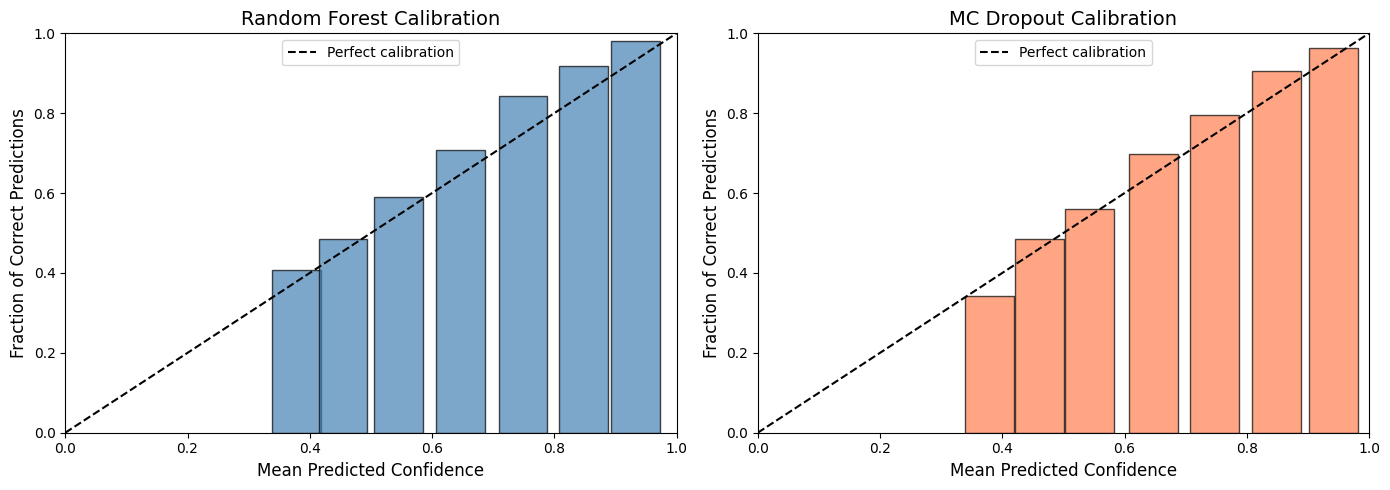

In [10]:
# Plot reliability diagram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[0].bar(rf_bin_conf, rf_bin_acc, width=0.08, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Mean Predicted Confidence', fontsize=12)
axes[0].set_ylabel('Fraction of Correct Predictions', fontsize=12)
axes[0].set_title('Random Forest Calibration', fontsize=14)
axes[0].legend()
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# MC Dropout
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
axes[1].bar(mc_bin_conf, mc_bin_acc, width=0.08, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_xlabel('Mean Predicted Confidence', fontsize=12)
axes[1].set_ylabel('Fraction of Correct Predictions', fontsize=12)
axes[1].set_title('MC Dropout Calibration', fontsize=14)
axes[1].legend()
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/07_confidence_calibration.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Summary statistics
print("\n" + "="*70)
print("SUMMARY: PREDICTION CONFIDENCE ANALYSIS")
print("="*70)

print(f"\nRandom Forest Model:")
print(f"  - Overall Accuracy: {accuracy_score(y_test, rf_pred):.3f}")
print(f"  - High Confidence (≥0.7) samples: {(rf_confidence >= 0.7).sum()} ({(rf_confidence >= 0.7).mean()*100:.1f}%)")
print(f"  - Accuracy on High Confidence: {accuracy_score(y_test[rf_confidence >= 0.7], rf_pred[rf_confidence >= 0.7]):.3f}")

print(f"\nMC Dropout Neural Network:")
print(f"  - Overall Accuracy: {accuracy_score(y_test, mc_pred):.3f}")
print(f"  - Mean Epistemic Uncertainty: {mc_uncertainty.mean():.3f}")

print("\n" + "="*70)
print("KEY TAKEAWAY: Confidence scores enable risk-aware decision-making")
print("in water quality monitoring applications.")
print("="*70)


SUMMARY: PREDICTION CONFIDENCE ANALYSIS

Random Forest Model:
  - Overall Accuracy: 0.635
  - High Confidence (≥0.7) samples: 2704 (23.6%)
  - Accuracy on High Confidence: 0.886

MC Dropout Neural Network:
  - Overall Accuracy: 0.623
  - Mean Epistemic Uncertainty: 0.083

KEY TAKEAWAY: Confidence scores enable risk-aware decision-making
in water quality monitoring applications.
